# <img src="./assets/course-icon.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

#### <a href="https://taldatech.github.io">Tal Daniel</a>

## Tutorial 04 - Differentiation & Autograd
---

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---

* [Matrix Calculus](#-Matrix-Calculus----Vector-&-Matrix-Derivatives)
* [Lagrange Multipliers](#-Lagrange-Multipliers)
* [Automatic Differentiation](#-Automatic-Differentiation-(AutoDiff,-AD))
    * [AutoDiff Forward Mode](#-AutoDiff-Forward-Mode)
    * [AutoDiff Reverse Mode](#-AutoDiff-Reverse-Mode)
* [PyTorch's Autograd](#-PyTorch's-Autograd)
    * [Tensor](#Tensor)
    * [Gradients](#Gradients)
* [Exam Question](#-Question-time!)
* [Recommended Videos](#-Recommended-Videos)
* [Credits](#-Credits)
  

In [1]:
# imports for the tutorial
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation, rc
from IPython.display import HTML
# %matplotlib ipympl
%matplotlib inline

## <img src="https://img.icons8.com/dusk/64/000000/scissors.png" style="height:50px;display:inline"> Matrix Calculus -  Vector & Matrix Derivatives
---
* We will use most of the derivatives "as is" without derivation.
* A good reference: **<a href="http://www2.imm.dtu.dk/pubdb/views/edoc_download.php/3274/pdf/imm3274.pdf">The Matrix Cookbook</a>**
* <img src="https://img.icons8.com/plasticine/100/000000/error.png" style="height:20px;display:inline"> **REMEMBER** - ALWAYS write the dimensions of each component and identify whether the expression is a **matrix, vector or scalar**!

### Gradient vs. Jacobian
---
<div style="width:100%;height:800px;line-height:3em;overflow:scroll;padding:5px;">

- **Gradient:**
  - Applies to functions $f: \mathbb{R}^n \to \mathbb{R}$.
  - It is a vector of partial derivatives:
    $$\nabla f(x) = \left( \frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_n} \right)^\top \in \mathbb{R}^n.$$

    - Example: Derivative of Vector Multiplication
        - Let $x, a \in \mathbb{R}^N \rightarrow x, a$ are **vectors**.        
        - $x^Ta = a^Tx$ are **scalars**
        - Derivation: $$ f (x) = x^Ta = [x_1, x_2, ..., x_n] \begin{bmatrix} a_{1} \\a_{2} \\ \vdots \\a_{n}\end{bmatrix}  = a_1 x_1 + a_2 x_2 + ... + a_n x_n = \sum_{i=1}^n a_i x_i$$ $$\nabla f(x) = \frac{\partial x^Ta}{\partial x} = \begin{bmatrix}\frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix} = \begin{bmatrix} a_{1} \\ a_{2} \\ \vdots \\ a_{n} \end{bmatrix} = a $$

- **Jacobian:**
  - Applies to functions $F: \mathbb{R}^n \to \mathbb{R}^m$.
  - Denote
    $$ F(x) = \begin{pmatrix}
    F_1(x) \\
    F_2(x) \\
    \vdots \\
    F_m(x)
    \end{pmatrix}
    $$
  - Then the Jacobian can be expressed as a matrix where each row is the gradient of one component function:
    $$J_F(x) =
    \begin{pmatrix}
    \nabla F_1(x)^\top \\
    \nabla F_2(x)^\top \\
    \vdots \\
    \nabla F_m(x)^\top
    \end{pmatrix} \in \mathbb{R}^{m\times n}.$$
  - In other words, the Jacobian collects the gradients of all $m$ scalar outputs of $F$.
      - Example: Matrix multiplication
          - Let $x \in \mathbb{R}^n$, $A \in \mathbb{R}^{m \times n}$.
          - $F: \mathbb{R}^{n} \rightarrow \mathbb{R}^{m}, F(x) = Ax$        

            $$ F (x) = Ax = \begin{bmatrix} A_{11}x_1 + A_{12}x_2 + \dots + A_{1n}x_n  \\ 
      A_{21}x_1 + A_{22}x_2 + \dots + A_{2n}x_n \\ \vdots \\ 
      A_{m1}x_1 + A_{m2}x_2 + \dots + A_{mn}x_n \end{bmatrix}  $$

$$ J_F(x) = \frac{\partial Ax}{\partial x} = \begin{bmatrix}
\frac{\partial F_1}{\partial x_1} &  \frac{\partial F_1}{\partial x_2} & \dots & \frac{\partial F_1}{\partial x_n} \\ 
\frac{\partial F_2}{\partial x_1} &  \frac{\partial F_2}{\partial x_2} & \dots & \frac{\partial F_2}{\partial x_n} \\ 
& & \vdots & \\
\frac{\partial F_m}{\partial x_1} &  \frac{\partial F_m}{\partial x_2} & \dots & \frac{\partial F_m}{\partial x_n} \\ 
\end{bmatrix} = 
\begin{bmatrix}
A_{11} &  A_{12} & \dots & A_{1n} \\ 
A_{21} &  A_{22} & \dots & A_{2n} \\ 
& & \vdots & \\
A_{m1} &  A_{m2} & \dots & A_{mn} \\ 
\end{bmatrix} = A
$$

</div>


### <img src="https://img.icons8.com/bubbles/100/000000/multiply.png" style="height:50px;display:inline"> Derivative of Vector Multiplication
---
* Let $x, a \in \mathbb{R}^N \rightarrow x, a$ are vectors.
* $\frac{\partial x^Ta}{\partial x} = \frac{\partial a^Tx}{\partial x} = a$
    * $x^Ta = a^Tx$ are **scalars**
    * $a$ is a **vector**
    * Derivation: $$ f = x^Ta = [x_1, x_2, ..., x_n] \begin{bmatrix} a_{1} \\a_{2} \\ \vdots \\a_{n}\end{bmatrix}  = a_1 x_1 + a_2 x_2 + ... + a_n x_n = \sum_{i=1}^n a_i x_i$$ $$\frac{\partial x^Ta}{\partial x} = \begin{bmatrix}\frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix} = \begin{bmatrix} a_{1} \\ a_{2} \\ \vdots \\ a_{n} \end{bmatrix} = a $$

#### <img src="https://img.icons8.com/cotton/64/000000/bunch-of-keys-1.png" style="height:30px;display:inline"> Common Derivatives
---
* $\nabla_x Ax = A^{T}$
* $\nabla_x \frac{1}{2}||x||^2 =  x$ 

* $\nabla_x x^{T} A x = (A + A^{T}) x$ 
    * If $W$ is **symmetric**:
        * $\frac{\partial}{\partial s} (x-As)^T W (x-As) = -2A^TW(x-As)$
        * $\frac{\partial}{\partial x} (x-As)^T W (x-As) = 2W(x-As)$
* $\frac{\partial}{\partial A} \ln |A| = A^{-T}$
* $\frac{\partial}{\partial A} Tr[AB] = B^{T}$

<!-- ### <img src="https://img.icons8.com/dusk/64/000000/link.png" style="height:50px;display:inline"> The Chain Rule
---
* Let $$ f(x) = h(g(x))$$ $$x \in \mathbb{R}^n $$ $$ f, g : \mathbb{R}^n \rightarrow \mathbb{R}$$ $$ h: \mathbb{R} \rightarrow \mathbb{R}$$
* $ \nabla f = h' \cdot \nabla g$. -->

### <img src="https://img.icons8.com/dusk/64/000000/link.png" style="height:50px;display:inline"> The Chain Rule

---
<div style="width:100%;height:800px;line-height:3em;overflow:scroll;padding:5px;">

#### Vector-to-Scalar Functions
  Let  
  $$
  f(x) = h(g(x)), 
  $$
  where
$$x \in \mathbb{R}^n $$
$$g : \mathbb{R}^n \to \mathbb{R}$$
$$h: \mathbb{R} \to \mathbb{R} \,.$$

- **Rule:**  
  The gradient is given by:
  $$
  \nabla f(x) = h'(g(x)) \, \nabla g(x).
  $$
  Here, $ h' $ is the scalar derivative of $ h $ evaluated at $ g(x) $, and $ \nabla g(x) $ is the gradient of $ g $.

---

#### Vector-to-Vector Functions

Let
  $$
  f(x) = h(g(x)),
  $$
  <!-- where $ g : \mathbb{R}^n \to \mathbb{R}^m $ and $ h : \mathbb{R}^m \to \mathbb{R}^p $. -->
  where 
$$x \in \mathbb{R}^n $$
$$g : \mathbb{R}^n \to \mathbb{R}^m$$
$$h: \mathbb{R}^m \to \mathbb{R}^p \,.$$

- **Rule:**  
  The derivative is expressed via Jacobian matrices multiplication:
  <!-- $$
  Df(x) = Dh(g(x)) \cdot Dg(x),
  $$ -->
  $$
  J_f(x) = J_h(g(x)) \cdot J_g(x),
  $$
  where:
  - $ J_h(g(x)) $ is the $ p \times m $ Jacobian of $ h $ evaluated at $ g(x) $.
  - $ J_g(x) $ is the $ m \times n $ Jacobian of $ g $ evaluated at $ x $.

</div>
<!-- 
- **Example:**  
  When $ f : \mathbb{R}^2 \to \mathbb{R}^2 $ is defined with specific functions $ g $ and $ h $, compute each Jacobian and multiply them to find $ Df(x) $.

---

These concise formulations extend the brief note by detailing both cases, emphasizing how the outer function’s derivative multiplies the inner function’s derivative (as gradient or Jacobian) in the composite function.
 -->

## <img src="https://img.icons8.com/office/80/000000/conflict.png" style="height:50px;display:inline"> Constrained Optimization
---
<details>
    <summary>Why?
</summary>
    We saw in the lecture that when $f(x)$ is given in a computation graph form,
    
- $ \min f(x) $ can be expressed as a constraint optimization problem
- The backpropagation algorithm is derived from Lagrange Multipliers solution

<details>
    <summary>
    <ins>Example</ins>        
    </summary>
<center><img src="./assets/computation_graph_example.png" style="height:400px"></center>
<details>
    <summary>
    We get the following optimization problem:    
    </summary>
$$\min d $$
$$\begin{aligned}
\textit{s.t.}  & \\
& \quad d = a * c \\
& \quad c = a + b
\end{aligned}$$

</details>

</details>


</details>
    
    





### <img src="https://img.icons8.com/dusk/64/000000/lambda.png" style="height:30px;display:inline"> Lagrange Multipliers
---
<div style="width:100%;height:800px;line-height:3em;overflow:scroll;padding:5px;">

* A method for optimization with **equality constraints**.
* The general case: $$ \min f(x,y), $$ $$ \textit{ s.t. (subject to) }: g(x,y)=0. $$
* The *Lagrange* function (*Lagrangian*) is defined by: $$ \mathcal{L}(x,y,\lambda) = f(x,y) -\lambda \cdot g(x,y). $$

* Geometric Intuition: let's look at the following figure where we wish to **maximize** $f(x,y)\ $  s.t  $\ g(x,y)=0$ - <br>
<center><img src="./assets/lagrange.jpg" style="height:400px"></center> <be>

* To maximize $f(x,y)$ subject to $g(x,y)=0$ means
    * Finding the largest value $c \in \{7,8,9,10,11\}$,
    * such that the level curve (contour) $f(x,y) = c$ intersects with $g(x,y)=0$
* This happens when the curves just touch each other (i.e. have a common tangent line)
* Otherwise, the value of $c$ could be increased

* Since the gradient of a function is **perperndicular** to the contour lines:
    * The *contour lines* of $f$ and $g$ are **parallel** iff the *gradients* of $f$ and $g$ are **parallel**.
    * Thus, we want points $(x,y)$ where $g(x,y) = 0$ and $$\nabla_{x,y}f(x,y)=\lambda \nabla_{x,y} g(x,y). $$
        * $\lambda$ - "The Lagrange Multiplier" is required to adjust the **magnitudes** of the (parallel) gradient vectors.

  </div>

###  <img src="https://img.icons8.com/dusk/64/000000/lambda.png" style="height:30px;display:inline"><img src="https://img.icons8.com/dusk/64/000000/lambda.png" style="height:30px;display:inline"> Multiple Constraints
---
* Extension of the above for problems with **multiple constraints** using a similar argument.
* The general case: minimize $f(x)$ s.t. $g_i(x)=0$, $i = 1,2,..., m$.
* The **Lagrangian** is a weighted sum of objective and constraint functions: $$ \mathcal{L}(x, \lambda_1, ..., \lambda_m) = f(x) - \sum_{i=1}^m \lambda_i g_i(x).$$
    * $\lambda_i$ is the Lagrange multiplier associated with $g_i(x) = 0$.
* The **solution** is obtained by solving the (unconstrained) optimization problem: $$\nabla_{x, \lambda_1, ..., \lambda_m}\mathcal{L}(x, \lambda_1, ..., \lambda_m) = 0 \iff \begin{cases}
    \nabla_x \big[f(x) - \sum_{i=1}^m \lambda_ig_i(x) = 0 \big]\\
    g_1(x) = ... = g_m(x) = 0
  \end{cases}$$
  * Amounts to solving $d + m$ equations in $d+m$ unknowns.
      * $d = |x|$ is the dimension of $x$.

## <img src="https://img.icons8.com/dusk/64/000000/graph.png" style="height:50px;display:inline"> Automatic Differentiation (AutoDiff, AD)
---
* Automatic differentiation is about computing derivatives of functions encoded as computer programs.
* It is a key component in every deep learning framework -- we want exact and efficient computation of derivatives.
* Challenges: may be **time-consuming** and **computationally expensive**.

<!-- ### <img src="https://img.icons8.com/dusk/64/000000/close-window.png" style="height:50px;display:inline"> AutoDiff Is NOT Numerical Differentiation
---
* Numerical differentiation is the technique that comes from the standard definition of a derivative: $$ \frac{df(x)}{dx}= \lim_{h \to 0} \frac{f(x+h )- f(x)}{h}.$$
* You can clearly approximate the left hand side by evaluating the right hand side at a small but non-zero $h$.
* It is very easy to code! but it costs $O(n)$ evaluations of $f$ for gradients in $n$ dimensions, and prone to errors (e.g., truncation error, precision errors). -->

### <img src="https://img.icons8.com/dusk/64/000000/close-window.png" style="height:50px;display:inline"> AutoDiff Is NOT Numerical Differentiation
---
* **Derivative (definition):** $$ \frac{df(x)}{dx}= \lim_{h \to 0} \frac{f(x+h )- f(x)}{h}.$$
* **Numerical diffrentiation:** Approximate with a small (but non-zero) $h$.
* <ins>Advantage:</ins> 
    * Easy to code! 
* <ins>Disadvantage:</ins>
    * Expensive - costs $O(n)$ evaluations of $f$ for gradients in $n$ dimensions
    * Numerical errors (e.g., truncation error, precision errors).

* Note: in the *center difference* version the errors are usually smaller: $$\frac{df(x)}{dx}= \lim_{h \to 0} \frac{f(x+h )- f(x-h)}{2h}. $$

Let's look at the following example:
$$ \text{func}(x) = 3x^3 -5x^2. $$ The derivative: $$ \text{dervf}(x) = 9x^2 -10x. $$

In [2]:
def func(x):
    return 3 * x ** 3 - 5 * x ** 2

def func_der(x):
    return 9 * x ** 2 -10 * x

Let's take a point  $x=1.5$. The derivative at this point is: $$ \text{dervf}(x=1.5) = 5.25 $$ This informs us that the slope of the tangent line to the graph of $\text{func}$ is 5.25. If we use the standard definition, we need to use a limit to reach this value. Let's see it.

Text(0.5, 0.65, 'derivative 5.25')

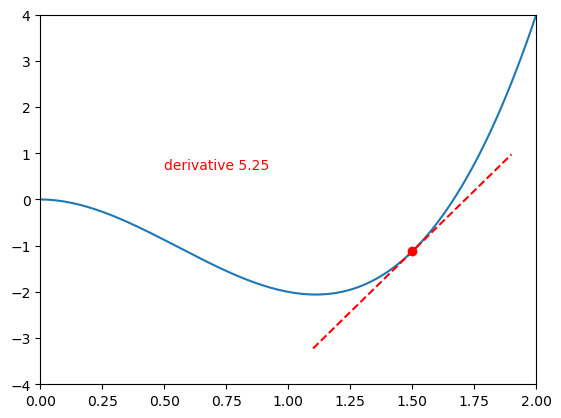

In [3]:
x = np.linspace(0,2,200)
y = func(x)
xprime = np.linspace(1.1,1.9)
yprime = (xprime - 1.5) * func_der(1.5)  + func(1.5)

fig, ax = plt.subplots()
ax.set_xlim(( 0, 2))
ax.set_ylim((-4, 4))
_,_,_, point, line = ax.plot(x,y, xprime, yprime, 'r--', [1.5], [func(1.5)], 'ro', [],[], 'ko', [], [], 'k-')
text = ax.text(0.5, 1, "")
ax.text(0.5, 0.65, "derivative 5.25", color="r")

In [4]:
def init():
    line.set_data([], [])
    point.set_data([], [])
    text.set_text("")
    return (point, line, text)
def animate(i):
    if (i < 45):
        pt = 1.495 - 0.495 * (60 - i) / 60
    elif (i < 75):
        pt = 1.495 - 0.495 * (16.25 - (i - 45) / 2 ) / 75
    elif (i < 80):
        pt = 1.495
    elif (i < 125):
        pt = 1.495 + 0.495 * (140 - i) / 60
    elif (i < 155):
        pt = 1.495 + 0.495 * (16.25 - (i - 125) / 2 ) / 75
    else:
        pt = 1.505
    x = np.linspace(0.8, 1.99)
    text.set_text("slope of the arc {0:.4f}".format((func(1.5) - func(pt))/(1.5 - pt)))
    y = (x - 1.5) * (func(1.5) - func(pt))/(1.5 - pt) + func(1.5)
    line.set_data(x, y)
    point.set_data([pt], [func(pt)])
    return (point, line, text)
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=160, repeat=True, blit=True)
HTML(anim.to_jshtml())

### <img src="https://img.icons8.com/dusk/64/000000/close-window.png" style="height:50px;display:inline"> AutoDiff Is NOT (Exactly) Symbolic Differentiation
---
* **Symbolic differentiation**: Programmatically produce the derivative expression of a given function.
    * Using the rules we learned in Calculus, e.g. $$ \frac{d(u(x) + v(x))}{dx} = \frac{du(x)}{dx} + \frac{dv(x)}{dx} $$ $$\frac{d(u(x)v(x))}{dx} = v(x)\frac{du(x)}{dx} + u(x)\frac{dv(x)}{dx}$$
$$\frac{du(v(x))}{dx} = \frac{du(v(x))}{dv} \frac{dv(x)}{dx}$$

<center><img src="./assets/symbolic_differentiation.png" style="height:300px"></center> <be>
You may have used this approach in the past...
    <center><img src="./assets/wolfram_symbolic_differentiation.png" style="height:300px"></center> <be>

* <ins>Advantage:</ins> 
    * Accurate (Exact expression)
* <ins>Disadvantage:</ins>
    * Complexity
        * We may get very long expressions
        * Hard to avoid duplicated computation of repeating expressions.


<!-- * One problem with symbolic differentiation is that you don't know how to calculate the derivative of a data structure, e.g., what is the derivative of the following: $$ \frac{d(\text{draw-point}(x,y))}{dx} $$ -->
<!-- 
* Another problem is that careless symbolic differentiation can easily produce exponentially large symbolic expressions which take exponentially long to evaluate. 
* For example, for the derivative of multiplication above, on the right hand side, $u(x)$ and $du(x)/dx$ appear separately. If you just proceed to symbolically differentiate $u$ and plug its derivative into the appropriate place, you will have **duplicated any computation that appears in common** between $u$ and $du$. -->

## <img src="https://img.icons8.com/cute-clipart/64/000000/fast-forward.png" style="height:50px;display:inline"> AutoDiff 
---
* **AutoDiff**: Given function $f(x)$ and input $x_0$, compute $f(x_0)$ and $\nabla f (x_0)$ "simultaneously"
    * <ins> Forward mode </ins>:
        * Compute $f(x_0)$ and $\nabla f (x_0)$ in parallel.
    * <ins> Reverse mode </ins>:
        * Compute $f(x_0)$ and store values required for $\nabla f (x_0)$
        * Compute $\nabla f (x_0)$ backwards.

* <ins>Advantage:</ins> 
    * Accurate (Exact expression)
    * Efficient: No long expressions.

<!-- 
## <img src="https://img.icons8.com/cute-clipart/64/000000/fast-forward.png" style="height:50px;display:inline"> AutoDiff Forward Mode
---
* In principle, exponentially large expressions should have lots of **duplication**, so it ought to be possible to simplify it to something fast afterwards—if you can store it in the memory long enough. 
* You can think of (forward mode) automatic differentiation as a way to organize symbolic differentiation to retain the sharing of intermediate results between the main computation and the derivative.
* AutoDiff comes in two basic flavors: *forward* and *reverse*. The easier basic flavor to describe and understand (and implement and use) is called **forward mode**, which computes **directional derivatives**.
* In Machine/Deep learning, we are actually using **reverse mode** for the backpropagation.  -->

### <img src="https://img.icons8.com/nolan/64/sorting-arrows-horizontal.png" style="height:50px;display:inline"> AutoDiff (Forward Mode)
---
Possible implementation using **"dual numbers"**.

A dual number gets the form $x + \epsilon x'$.

Properties (not a formal definition):
1. $\epsilon^2=0$
2. $ f(x+\epsilon x') = f(x) +\epsilon f'(x)x'. $
3. $ (x + \epsilon x') + (y + \epsilon y') = (x+y) + \epsilon(x' + y') $
4. $  (x + \epsilon x')(y + \epsilon y') = xy +\epsilon(x'y + xy')$

* **Motivation**: Create a data structure for carrying the derivative together with the "undifferentiated" answer (called the *primal*). 

* Consider the **Chain rule**: $$ f(g(x +\epsilon x')) = f(g(x) +\epsilon g'(x)x') $$ $$ = f(g(x)) + \epsilon f'(g(x))g'(x)x' $$

    *  The coefficient of $\epsilon$ on the right hand side is exactly the <ins>derivative of the composition of $f$ and $g$</ins>.
    * $\Rightarrow$ We can extract the derivative of a function by evaluating it on the dual number $x + 1\cdot \epsilon$: $$ \left.\frac{df(x)}{dx} \right|_x = \text{coefficient-of-epsilon}(\text{dual-version}(f)(x+1\cdot \epsilon)). $$

<!-- ### <img src="https://img.icons8.com/nolan/64/sorting-arrows-horizontal.png" style="height:50px;display:inline"> AutoDiff Forward Mode Computes Directional Derivatives
---
* To do forward mode AD on a program, you need to do a non-standard interpretation of the program.
* Define **“dual numbers”** as formal **truncated Taylor series** of the form $x + \epsilon x'$.
* Define arithmetic on dual numbers by $\epsilon^2 = 0$, and by interpreting *any* non-dual number $y$ as $y + \epsilon \cdot 0$. This yields: $$ (x + \epsilon x') + (y + \epsilon y') = (x+y) + \epsilon(x' + y') $$ $$  (x + \epsilon x')(y + \epsilon y') = xy +\epsilon(x'y + xy')$$
    * Notice there is no quadratic term in the second equation as $\epsilon^2=0$.
    * The coefficients of $\epsilon$ should look familiar: they are just the corresponding symbolic derivative rules.
* **WHY** are we doing this? We are basically setting up a regime where: $$ f(x+\epsilon x') = f(x) +\epsilon f'(x)x'. $$
    * In other words, these dual numbers are just data structures for carrying the derivative around together with the undifferentiated answer (called the *primal*).  -->

<!-- #### What About The Chain Rule?
---
* It still works! (start from the inside) $$ f(g(x +\epsilon x')) = f(g(x) +\epsilon g'(x)x') $$ $$ = f(g(x)) + \epsilon f'(g(x))g'(x)x' $$
    *  The coefficient of $\epsilon$ on the right hand side is exactly the derivative of the composition of $f$ and $g$.
* This means that we can extract the derivative of a function of interest by evaluating it in this non-standard way on an initial input with a 1 coefficient for $\epsilon$: $$ \left.\frac{df(x)}{dx} \right|_x = \text{coefficient-of-epsilon}(\text{dual-version}(f)(x+1\cdot \epsilon)). $$
* This also generalizes naturally to taking directional derivatives of $\mathcal{R}^n \to \mathcal{R}^m$. -->

<!-- * This mechanism works for any function that can be composed out of the primitive operations that we have extended to dual numbers. 
* It turns every arithmetic operation into a fixed number of new arithmetic operations, so the arithmetic cost goes up by a small constant factor.
* This technique also naturally extends to arbitrary program constructs—dual numbers are just data, so things like data structures can just contain them. 
    * As long as no arithmetic is done on the dual number, it will just sit around and happily be a dual number; and if it is ever taken out of the data structure and operated on again, then the differentiation will continue. -->

#### Example
--- 
<details>
    <summary>
Let $ f(x) = cos(x)^2 $.
Compute $f(x)$ and $f'(x)$ at $x=\frac{\pi}{4}$.
        
</summary>
We get
$$
\begin{aligned}
f \left( \frac{\pi}{4} + 1\epsilon \right) &= \left( \cos \left( \frac{\pi}{4} + 1\epsilon  \right) \right)^2 \\
&= \left( \cos \left( \frac{\pi}{4} \right) - \sin \left( \frac{\pi}{4} \right) \epsilon   \right)^2 \\
&= \left( \frac{1}{\sqrt{2}} - \frac{1}{\sqrt{2}} \epsilon   \right)^2 \\
&= \left( \frac{1}{\sqrt{2}} \right) ^ 2 + 2 \left( \frac{1}{\sqrt{2}} \right) \left( - \frac{1}{\sqrt{2}} \epsilon   \right) \\
&= \frac{1}{2} -1 \epsilon
\end{aligned}
$$

$$
\Rightarrow f\left( \frac{\pi}{4} \right) = \frac{1}{2},\, f'\left( \frac{\pi}{4} \right) = -1
$$
</details>



#### Jacobian Matrix Perspective of Forward AutoDiff
---
Consider a more general approach:
* Assume a function $f: \mathcal{R}^n \to \mathcal{R}^m$ consists of a sequence of primitive operations:
 $$f(x) = f_k \circ ... \circ f_3 \circ f_2 \circ f_1 (x)$$ for $k$ primitive operations, with data flowing from right to left

* Define the the partial-result function $f^i$ as: $$ f^i = f_i \circ ... \circ f_3 \circ f_2 \circ f_1,$$

* Then the full Jacobian of $f$ decomposes as:
<!-- $$ J_xf = J_{f^{k-1}(x)}f_k \cdot ... J_{f^{2}(x)}f_3 \cdot J_{f^{1}(x)}f_2 \cdot J_{x}f_1 .$$ -->
$$ J_xf = J_{f^{k-1}(x)}f_k \cdot ... J_{f^{2}(x)}f_3 \cdot J_{f^{1}(x)}f_2 \cdot J_{x}f_1 $$
* Note that the full Jacobian $Jf$ may be a huge dense matrix, yet each of the pieces $Jf_i$ is often **very sparse**, because each primitive $f_i$ only operates on a tiny part of the data.
<!-- *  So we can look at the result of forward-mode automatic differentiation as an implicit representation of the point-indexed family of matrices $J_xf$ in the form of a program that computes matrix-vector products $J_xf\cdot v$ given $x$ and $v$. -->

<!-- #### Jacobian Matrix Perspective of Forward AutoDiff
---
* Another way to look at forward mode of a function $f: \mathcal{R}^n \to \mathcal{R}^m$ is to consider the **Jacobian** (matrix of partial derivatives) $J_x f \in \mathcal{R}^{m \times n}$ at some point $x \in \mathcal{R}^n$.
* The function $f$ consists of a sequence of primitive operations applied to various data in its internal storage.
* If we call this sequence $f_k \circ ... \circ f_3 \circ f_2 \circ f_1$ (for $k$ primitive operations, with data flowing from right to left), and we define the the partial-result function $f^i$ as: $$ f^i = f_i \circ ... \circ f_3 \circ f_2 \circ f_1,$$ then the full Jacobian of $f$ decomposes as: $$ J_xf = J_{f^{k-1}(x)}f_k \cdot ... J_{f^{2}(x)}f_3 \cdot J_{f^{1}(x)}f_2 \cdot J_{x}f_1 .$$
* The nice thing about this decomposition is that even though the full Jacobian $Jf$ may be a horrible huge dense matrix, each of the pieces $Jf_i$ is necessarily **very sparse**, because each primitive $f_i$ only operates on a tiny part of the data.
*  So we can look at the result of forward-mode automatic differentiation as an implicit representation of the point-indexed family of matrices $J_xf$ in the form of a program that computes matrix-vector products $J_xf\cdot v$ given $x$ and $v$. -->

* Forward Mode **Advantage**:
    * For any additional *output* the additional required number of steps is just 1 ($\frac{\partial y_2}{\partial x_1}$ below).
* Forward Mode **Disadvantage**:
    * For any additional *input*, we need to perform the whole computation again ($\frac{\partial y}{\partial x_2}$ below), may be expensive computationally as the input dimension grows.

<center><img src='./assets/autodiff_fm_add_output.png' style="height:400px"></center>

## <img src="https://img.icons8.com/dusk/64/000000/rewind.png" style="height:50px;display:inline"> AutoDiff Reverse Mode
---
In practice, we usually only need the gradient of the <ins>loss function</ins> $f:\mathbb{R}^n \to \mathbb{R}$.

In this case, the reverse mode is more efficient:
* Compute $f(x_0)$ and store values required for $\nabla f (x_0)$
* Compute $\nabla f (x_0)$ backwards.

<center><img src="./assets/backprop_anim.gif" style="height:400px"></center>
<a href="https://anatomiesofintelligence.github.io/posts/2018-10-16-forward-back-propogation">Image Source</a>

<ins>Example</ins>
* Let's say we have a scalar function: $$ d = a*(a+b) $$
* We will define an intermediate variable $c=a+b$ and draw the <ins>computational graph</ins>.
* At this point, we can also draw the <ins>gradient computational graph</ins>.
    * Edge $(u,v)$ contains the primitive $\frac{\partial v}{\partial u}$ 
<center><img src="./assets/autodiff_graph_example.png" style="height:500px"></center>

* Ones finishing computing the output ($d$), we can compute it's derivaitives w.r.t. the inputs.

* Notes:
    * The back propagation step always has the **same complexity** as the original forward propagation step.
    * Reverse Mode **Advantage**:
        * For any additional *input* the additional required number of steps is just 1 ($\frac{\partial y}{\partial x_2}$ above), in complexity terms.
    * Reverse Mode **Disadvantage**:
        * For any additional *output*, we need to perform the whole computation again ($\frac{\partial y_2}{\partial x_1}$ above).


## <img src="https://img.icons8.com/dusk/64/000000/rewind.png" style="height:50px;display:inline"> AutoDiff Reverse Mode
---
* In optimizing neural networks, unlike *forward mode*, gradients of functions $f:\mathcal{R}^n \to \mathcal{R}$ are generally much more valuable: they enable multidimensional optimization methods, multiparameter sensitivity analyses, simulations of systems following potentials, etc.
* The concept for a gradient of $f:\mathcal{R}^n \to \mathcal{R}$ generalizes trivially to directional gradients of $g:\mathcal{R}^n \to \mathcal{R}^m$.
* You can read more about **reverse mode**, which computes **directional gradients** <a href="https://alexey.radul.name/ideas/2013/introduction-to-automatic-differentiation">here</a>.

### <img src="https://img.icons8.com/nolan/64/sorting-arrows-horizontal.png" style="height:50px;display:inline"> AutoDiff Reverse Mode Computes Directional Gradients
---
* The **directional gradient** is a symmetric concept to **directional derivative**: where the directional **derivative** in the direction $v$ is $J_xf\cdot v$, the directional **gradient** is $u^T \cdot J_xf$.
* The decomposition of $Jf$ as introduced in the forward mode is still a good representation. However, unlike directional derivatives, for directional gradients, they flow in opposite directions, necessitating computing and storing some explicit representation of the decomposition, based on the point $x$, first, before being able to multiply through by $u^T$ to compute the desired gradient.
* Reverse mode introduces both code complexity and runtime cost in the form of managing this storage. In particular, the space requirements of raw reverse mode are proportional to the runtime of $f$.

<center><img src="./assets/backprop_anim.gif" style="height:350px"></center>

<a href="https://anatomiesofintelligence.github.io/posts/2018-10-16-forward-back-propogation">Image Source</a>

<center><img src="./assets/autograd_reverse_mode.gif" style="height:350px"></center>

<a href="https://penny-xu.github.io/blog/pytorch-autograd">Image Source- Penny Xu</a>

* Let's say we have a scalar function: $$ d = a*(a+b) $$
* It is rather easy calculating the derivatives of this function: $\frac{\partial d}{\partial a} = 2a + b, \frac{\partial d}{\partial b}=a$.
* But for more complicated functions, the expression might blow up.
* We will define an intermidiate variable $c=a+b$ and draw the computational graph.

<center><img src="./assets/autodiff_graph_example.png" style="height:350px"></center>

* Then, we can mechanically write down the derivatives of the individual terms. 
* Given all these, we can work backwards to compute the derivative of $f$ with respect to each variable.
    * This is just an application of the chain rule.
* In this way, we can work backwards from the end of the graph, computing the derivative of each variable, making the use of the derivatives of the children of that variable.
* It works for any differentiable function that can be phrased as an **expression graph** (or **computational graph**). One can really think of this as differentiating programs, rather than “functions”. 
* The back propagation step always has the **same complexity** as the original forward propagation step.


* Reverse Mode **Advantage**: for any additional *input* the additional required number of steps is just 1 ($\frac{\partial y}{\partial x_2}$ above), in complexity terms.
* Reverse Mode **Disadvantage**: for any additional *output*, we need to perform the whole computation again ($\frac{\partial y_2}{\partial x_1}$ above).

Illustration: <center><img src="./assets/autograd_reverse_mode_static.jpg" style="height:350px"></center>

<a href="https://penny-xu.github.io/blog/pytorch-autograd">Image Source- Penny Xu</a>

<center><img src="./assets/autodiff_fw_vs_bw.jpg" style="height:350px"></center>

<a href="https://towardsdatascience.com/forward-mode-automatic-differentiation-dual-numbers-8f47351064bf">Image Source- Robert Lange</a>

## <img src="https://img.icons8.com/color/48/000000/fire-element.png" style="height:50px;display:inline" /> PyTorch's Autograd
---
<center><img src="./assets/pytorch_logo.png" style="height:100px" /></center>

At its core, PyTorch provides two main features:

* An n-dimensional Tensor, similar to `numpy` but can run on GPUs.
* Automatic differentiation for building and training neural networks.

The word "Tensor" might seem initmidating, but it is just an $n$-dimensional array or matrix.  A **PyTorch Tensor** is conceptually identical to a `numpy` array: a Tensor is an $n$-dimensional array, and PyTorch provides many functions for operating on these Tensors. 

Behind the scenes, Tensors can keep track of a computational graph and gradients, but they’re also useful as a generic tool for scientific computing. 

Most of the functions and methods available in `numpy` are also available in PyTorch for tensors.


<center><img src="./assets/tensor.jpg" style="height:400px" /></center>

<a href="https://research.macrosynergy.com/analyzing-global-fixed-income-markets-with-tensors/">Image Source</a>


Central to all neural networks in PyTorch is the `autograd` package. The `autograd` package provides automatic differentiation for all operations on Tensors, natively implemented in PyTorch and works on Tensors.

#### Why not just use NumPy?
NumPy is a great framework, but it cannot utilize GPUs to accelerate its numerical computations (but check out <a href="https://numba.pydata.org/">Numba</a> to accelerate `numpy` computations). For modern deep neural networks, GPUs often provide speedups of 50x or greater, so unfortunately numpy won’t be enough for modern deep learning.

In [5]:
# create a tensor initialized from a random uniform distribution
x = torch.Tensor(5, 3).uniform_(-1, 1)
print("x: \n", x)
print("x size:", x.size())
print("same as x shape:", x.shape)

x: 
 tensor([[-0.3657, -0.1805, -0.5845],
        [ 0.9075,  0.9514,  0.5311],
        [-0.6133,  0.0563, -0.0852],
        [ 0.8035, -0.5382,  0.8623],
        [ 0.5821,  0.7476, -0.6193]])
x size: torch.Size([5, 3])
same as x shape: torch.Size([5, 3])


In [6]:
# numpy -> torch
z = torch.tensor(np.array([[1, 2], [3, 4]]))  # best practice
print("z: \n", z)

# numpy -> torch, old alternative verion
a = np.array([[1, 2], [3, 4]])
z = torch.from_numpy(a)  # slower than torch.tensor(a)
print("z: \n", z)

# torch -> numpy
p = x.numpy()  # better: p = x.cpu().numpy() if `x` is on the GPU
print("p = x.numpy(): \n", p)

z: 
 tensor([[1, 2],
        [3, 4]])
z: 
 tensor([[1, 2],
        [3, 4]])
p = x.numpy(): 
 [[-0.36574733 -0.18050468 -0.58445954]
 [ 0.9075457   0.9513885   0.53112984]
 [-0.6132672   0.0563426  -0.08517385]
 [ 0.803543   -0.53823495  0.8622552 ]
 [ 0.5820583   0.7476162  -0.6193397 ]]


#### Tensor
---
* `torch.Tensor` is the central class of the package.
* If you set its attribute `.requires_grad` as `True`, it starts to track all operations on it. 
* When you finish your computation you can call `.backward()` and have all the gradients computed automatically. 
* The gradient for this tensor will be **accumulated** into `.grad` attribute.
* To stop a tensor from tracking history, you can call `.detach()` to detach it from the computation history, and to prevent future computation from being tracked.
    * To prevent tracking history (and using memory), you can also wrap the code block in `with torch.no_grad(): <code>`. This can be particularly helpful when evaluating a model because the model may have trainable parameters with `requires_grad=True`, but for which we don’t need the gradients.

In [7]:
# Create a tensor and set requires_grad=True to track computation with it
x = torch.ones(2, 2, requires_grad=True)
print("x = \n", x)
# print("x.grad = \n", x.grad)

x = 
 tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


In [8]:
# perform some operation on the tensor
y = x + 2
print("y = \n", y)

y = 
 tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


* `y` was created as a result of an operation, so it has a `grad_fn`.
    * Note that the gradients have not been calculated yet.

In [9]:
print(y.grad_fn)

In [10]:
# do even more operations on the tensor
z = y * y * 3
out = z.mean()

print("z = \n", z)
print("out = \n" , out)

z = 
 tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>)
out = 
 tensor(27., grad_fn=<MeanBackward0>)


#### Gradients
---
* Let’s backprop now! 
* Because `out` contains a **single scalar**, `out.backward()` is equivalent to `out.backward(torch.tensor(1.))`.

In [11]:
# backpropagation
out.backward()

In [12]:
# Print gradients d(out)/dx
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


* What happend here?

Let’s call the ``out`` *Tensor* “$o$”.
We have that $$o = \frac{1}{4}\sum_{i=1}^{4} z_i,$$
$$z_i = 3(x_i+2)^2,$$ $$ \to o = \frac{3}{4}\sum_{i=1}^{4} (x_i+2)^2 $$ and $$z_i\bigr\rvert_{x_i=1} = 27.$$
Therefore,
$$\frac{\partial o}{\partial x_i} = \frac{3}{2}(x_i+2),$$ hence
$$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=1} = \frac{9}{2} = 4.5 .$$

#### Limitations
---
* AutoGrad is limited to scalar outputs (i.e. loss functions).
    * We can compute the derivative of $f: \mathbb{R}^n \rightarrow \mathbb{R}^m$ using $m$ backward iterations.

* Retains gradients only for `leaf' Tesneors (can be bypassed)

Mathematically, if you have a vector valued function $\vec{y}=f(\vec{x})$,
then the gradient of $\vec{y}$ with respect to $\vec{x}$
is a **Jacobian matrix**:

\begin{align}J=\left(\begin{array}{ccc}
   \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
   \vdots & \ddots & \vdots\\
   \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
   \end{array}\right)\end{align} 

<br>

* Generally speaking, ``torch.autograd`` is an engine for computing **vector-Jacobian product**. 
* That is, given any vector $v=\left(\begin{array}{cccc} v_{1} & v_{2} & \cdots & v_{m}\end{array}\right)^{T}$ compute the product $v^{T}\cdot J$. 
* If $v$ happens to be the gradient of a scalar function $l=g\left(\vec{y}\right)$, that is, $v=\left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}$, then by the chain rule, the vector-Jacobian product would be the gradient of $l$ with respect to $\vec{x}$:

\begin{align}J^{T}\cdot v=\left(\begin{array}{ccc}
   \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
   \vdots & \ddots & \vdots\\
   \frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
   \end{array}\right)\left(\begin{array}{c}
   \frac{\partial l}{\partial y_{1}}\\
   \vdots\\
   \frac{\partial l}{\partial y_{m}}
   \end{array}\right)=\left(\begin{array}{c}
   \frac{\partial l}{\partial x_{1}}\\
   \vdots\\
   \frac{\partial l}{\partial x_{n}}
   \end{array}\right)\end{align}

(Note that $v^{T}\cdot J$ gives a row vector which can be treated as a column vector by taking $J^{T}\cdot v$.)

Let's take a look at an example of vector-Jacobian product!

In [13]:
x = torch.randn(3, requires_grad=True)

y = x * 2
while y.data.norm() < 1000:
    y = y * 2

print(y)

tensor([-977.1429, -812.3446,  268.1271], grad_fn=<MulBackward0>)


Now in this case ``y`` is no longer a scalar. ``torch.autograd``
could not compute the full Jacobian directly, but if we just
want the vector-Jacobian product, simply pass the vector to
``backward`` as argument:

In [14]:
# let's say vector (tensor) v is the gradient of some scalar function 
# (graph where in the backward pass x<-y<-z...<-f, df/dz=v)
v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(v)

print(x.grad)

tensor([5.1200e+01, 5.1200e+02, 5.1200e-02])


You can also stop autograd from tracking history on Tensors
with ``.requires_grad=True`` either by wrapping the code block in
``with torch.no_grad():``

In [15]:
print(x.requires_grad)
print((x ** 2).requires_grad)

with torch.no_grad():
    print((x ** 2).requires_grad)

True
True
False


Or by using ``.detach()`` to get a new Tensor with the same
content but that does not require gradients:

In [16]:
print(x.requires_grad)
y = x.detach()
print(y.requires_grad)
print(x.eq(y).all())

True
False
tensor(True)


<center><img src="./assets/torch_dynamic_graph.gif" style="height:350px"></center>

<a href="https://github.com/SsnL/pytorch">Image Source</a>

### <img src="https://img.icons8.com/cotton/64/000000/stop-sign.png" style="height:50px;display:inline"> Question time!
---
This question is from Spring 2024 Moed A

We model continuous-time ordinary differential equations (ODE) (מד"ר) 
using a specialized neural network called a *Neural ODE*.

* For example, we are given initial weather condition $v_0$ and would like to predict the weather at time $T$ ($v_T$).
* We do that by modeling the weather's <ins>dynamical system</ins>.

Formally, 
\begin{align}  \tag{*}
\forall t\in [0,T]:\quad \frac{dv(t)}{dt}=f(w,v(t),t)
\end{align}
 with:
* Neural network $f$ with parameters $w\in\mathbb{R}^p$,
* State $v(t) \in\mathbb{R}^d$,
* Starting condition $v(0) = v_0$,
* Cost function $C=\frac{1}{2}||v(T)||^2$.
* Assume we have a 'black-box' ODE solver to compute $v(t)$ given $(*)$ and $v(0)$.

Note that $v(t)$ is a function of $w$ (except for $t=0$) and so $C$ is also a function of $w$. 

We wish to find a system of differential equations that solve $\nabla C(w)$ in order to find $w$ via gradient descent. 

We do this via both **forward-mode** and **reverse-mode** autodiff.

#### Part 1: Forward Mode
1. In order to compute $\nabla C(w)$ we need to compute $\frac{dv(t)}{dw}$. To do that, we solve another ODE:

    Let $$a(t)\triangleq \frac{dv(t)}{dw}.$$ Find an ODE for $a(t)$ of the form $$\forall t\in [0,T]:\quad \frac{da(t)}{dt}=g(w,v(t),a(t),t)$$
    where $g$ may be a function of $f$ and its partial derivatives $\frac{\partial f(w,v(t),t)}{\partial w},\frac{\partial f(w,v(t),t)}{\partial v(t)}$.
    hint: use partial derivatives, chain rule, note the differences between a derivative and a partial derivative.
    
3.  * What is the starting condition at $t=0$ of the ODE you found?
    * Given the solution to $(*)$ and the ODE from section 1, how would we calculate $\nabla C(w)$?
    
        Hint: use the chain rule.
      

####  <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time! (Part 1)


#### Section 1

<!-- <span style="color:gray">

Let $$a(t)\triangleq \frac{dv(t)}{dw}.$$ Find an ODE for $a(t)$ of the form $$\forall t\in [0,T]:\quad \frac{da(t)}{dt}=g(w,v(t),a(t),t)$$
    where $g$ may be a function of $f$ and its partial derivatives $\frac{\partial f(w,v(t),t)}{\partial w},\frac{\partial f(w,v(t),t)}{\partial v(t)}$.
    hint: use partial derivatives, chain rule, note the differences between a derivative and a partial derivative.
</span> -->

$$\frac{da(t)}{dt} = \frac{d}{dt}\frac{dv(t)}{dw}$$
Substitute order of derivatives and get
$$\frac{da(t)}{dt}=\frac{d}{dw}\frac{dv(t)}{dt}$$
and by plugging the expression we get 
$$\frac{da(t)}{dt}=\frac{d}{dw}f(w,v(t),t)$$

By using the chain rule we get

$$\frac{d}{dw}f(w,v(t),t)=\frac{\partial}{\partial w}f(w,v(t),t)+\frac{\partial}{\partial v(t)}f(w,v(t),t)\frac{dv(t)}{dw}$$

And finally 
$$\frac{da(t)}{dt}=\frac{\partial f(w,v(t),t)}{\partial w}+\frac{\partial f(w,v(t),t)}{\partial v(t)}a(t)$$

#### Section 2
<span style="color:gray">
    
1. What is the ODE's starting condition at $t=0$? 
2. Given the solution to $(*)$ and the ODE from section 1, how would we calculate $\nabla C(w)$?
   
   Hint: Chain rule.

<!-- Hint: To calculate $\nabla C(w)$, we need to calculate $v(T),a(T)$. -->

</span>

1. Recall we defined $a(t)\triangleq \frac{dv(t)}{dw}$. Since $v(0)$ is not a function of $w$, we get $$a(0)=\frac{d v(0)}{d w}=0\,.$$
Then we can solve the ODE we found to get $a(T)$.

2. After solving the ODEs and getting $a(T)$ and $v(T)$, we can compute $\nabla C(w)$:
   $$\begin{aligned}
   \nabla C(w) & = \frac{d}{dw} \left( \frac{1}{2} ||v(T)||^2 \right) \\ \\
   & = \frac{d}{dv}  \left( \frac{1}{2} ||v(T)||^2 \right) \cdot \frac{\partial v(T)}{\partial w} \\ \\
   & = v(T)^\top  a(T).
   \end{aligned}$$

#### Reverse Mode

3. We will now consider a different approach. First, we define the problem's Lagrangian $\mathcal{L}(w,v,b,\lambda)$ as
    $$\frac{1}{2}||v(T)||^2+\int_{0}^{T} b(t)^\top\left (f(w,v(t),t)-\frac{dv(t)}{dt}\right )dt+\lambda^\top (v_0-v(0))$$
    Explain the origins of each of the Lagrangian's three terms.

4. Show that the integral term can be written as the following term via integration by parts.
    $$\int_{0}^{T} \left (b(t)^\top f(w,v(t),t)+\frac{d b(t)^\top}{dt}v(t)\right )dt-b(T)^\top v(T)+b(0)^\top v(0)$$
   

5. From the stationarity conditions of the Lagrangian $\forall t\in (0,T),\quad \frac{\partial\mathcal{L}}{\partial v(t)}=0$, find an ODE for $b(t)$ of the form $$\forall t\in (0,T):\quad \frac{db(t)}{dt}=h(w,v(t),b(t),t)$$
where $h$ may be a function of $f$ and its partial derivatives $\frac{\partial f(w,v(t),t)}{\partial w},\frac{\partial f(w,v(t),t)}{\partial v(t)}$.

6. From the stationarity condition $\frac{\partial\mathcal{L}}{\partial v(T)}=0$, find the starting conditions for section 5 for $t=T$. Assume that the ODE applies for $t\in[0,T]$.

7. How can we calculate $\nabla C(w)$ given the solution to $(*)$ and the ODE from section 5? Hint: what are the remaining stationarity conditions?

8. Of the two methods described (sections 1-2, sections 3-7), which is forward-mode and which is reverse-mode? Give one disadvantage for each method that is specific to this neural ODE setting.

### <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time!


<!-- a$\$a\frac{da(t)}{dt}=\frac{d}{dw}\frac{dv(t)}{dt}=\frac{d}{dw}f(w,v( ),t)
$$\frac{da(t)}{dt}=\frac{d}{dw}\frac{dv(t)}{dt}=\frac{d}{dw}f(w,v(t),t) =\frac{\partial}{\partial w}f(w,v(t),t)+\frac{\partial}{\partial v(t)}f(w,v(t),t)\frac{dv(t)}{dw}$$
$$\frac{da(t)}{dt}=\frac{\partial f(w,v(t),t)}{\partial w}+\frac{\partial f(w,v(t),t)}{\partial v(t)}a(t)$$ -->


<!-- 
Solving $(*)$ gives us $v(t)$ for all $t\in[0,T]$. Since $v_0$ does not depend on $w$, $a(0)=\frac{d v(0)}{d w}=0$. We can use the ODE from section 1 to then calculate $a(t)$ for all $t\in[0,T]$. Finally, $$\nabla C(w)=\frac{d}{dw}||v(T)||^2=v(T)^T\frac{\partial v(T)}{\partial w}=v(T)^T a(T).$$ -->

#### Section 3
<span style="color:gray">
     We will now consider a different approach. First, we define the problem's Lagrangian $\mathcal{L}(w,v,b,\lambda)$ as
    $$\frac{1}{2}||v(T)||^2+\int_{0}^{T} b(t)^\top\left (f(w,v(t),t)-\frac{dv(t)}{dt}\right )dt+\lambda^\top (v_0-v(0))$$
    Explain the origins of each of the Lagrangian's three terms.
</span>

Similar to the lecture, we formulate the problem as a constraint optimization problem.
$$\min \frac{1}{2}||v(T)||^2$$
$$\begin{aligned}
\textit{s.t.}  & \\
& \quad \forall t\in [0,T]:\quad   \frac{dv(t)}{dt}=f(w,v(t),t) \\
& \quad v \left( 0 \right) = v_0
\end{aligned}$$


In the Lagrangian above, we have 
1. The first term is the cost function.
2. The second term (the integral) is the constraint that the ODE $(*)$ holds for all $t\in[0,T]$.
   
   Note we use integral here since we have constraint for each (continuous) $t$.
4. The last term is the constraint that $v_0=v(0)$. $\lambda$,$b(t)$ are Lagrange multipliers.

Stationary condition: $\nabla_{w,v,b,\lambda} \mathcal{L}(w,v,b,\lambda) = 0$

#### Section 4
<span style="color:gray">
    Show that the integral term can be written as the following term via integration by parts.
    $$\int_{0}^{T} \left (b(t)^\top f(w,v(t),t)+\frac{d b(t)^\top}{dt}v(t)\right )dt-b(T)^\top v(T)+b(0)^\top v(0)$$
</span>

Reminder:
$$\int_{a}^{b} u(x)v'(x) dx = \left[u(x) v(x) \right]_{a}^{b} - \int_{a}^{b} u'(x)v(x)dx$$

Integration by parts:
$$\int_{0}^{T} b(t)^\top \frac{dv(t)}{dt}dt=b(T)^\top v(T)-b(0)^\top v(0)-\int_0^T \frac{db(t)^\top }{dt}v(t)dt$$

We have
$$\int_{0}^{T} b(t)^\top \left (f(w,v(t),t)-\frac{dv(t)}{dt}\right )dt = 
\int_{0}^{T} b(t)^\top f(w,v(t),t) dt - \int_{0}^{T} b(t)^\top \frac{dv(t)}{dt}dt$$

By plugging the expression above we get
$$\int_{0}^{T} \left (b(t)^\top f(w,v(t),t)+\frac{d b(t)^\top }{dt}v(t)\right )dt-b(T)^\top v(T)+b(0)^\top v(0)$$

Finally we get the Lagrangian 
$$
\mathcal{L}(w,v,b,\lambda) = \frac{1}{2}||v(T)||^2 + 
\lambda^\top (v_0-v(0)) + 
\int_{0}^{T} \left (b(t)^\top f(w,v(t),t)+\frac{d b(t)^\top}{dt}v(t)\right )dt-b(T)^\top v(T)+b(0)^\top v(0)
$$

#### Section 5
<span style="color:gray">
From the stationarity conditions of the Lagrangian $\forall t\in (0,T),\quad \frac{\partial\mathcal{L}}{\partial v(t)}=0$, find an ODE for $b(t)$ of the form $$\forall t\in (0,T):\quad \frac{db(t)}{dt}=h(w,v(t),b(t),t)$$
where $h$ may be a function of $f$ and its partial derivatives $\frac{\partial f(w,v(t),t)}{\partial w},\frac{\partial f(w,v(t),t)}{\partial v(t)}$.
</span>

For $t\in(0,T)$, deriving the Lagrangian by $v(t)$:
$$\frac{\partial\mathcal{L}}{\partial v(t)}=\frac{db(t)^\top}{dt}+b(t)^\top \frac{\partial}{\partial v(t)}f(w,v(t),t)=0$$
Moving terms, we get
$$\frac{db(t)}{dt}=-\left [\frac{\partial f(w,v(t),t)}{\partial v(t)}\right]^\top b(t)$$

#### Section 6
<span style="color:gray">
From the stationarity condition $\frac{\partial\mathcal{L}}{\partial v(T)}=0$, find the starting conditions for section 5 for $t=T$. Assume that the ODE applies for $t\in[0,T]$.

</span>

If the ODES holds for all $t\in [0,T]$, the integral term in $\mathcal{L}$ drops since the constraint is satisfied. To find starting conditions for $t=T$ we need to derive by $v(T)$:
$$\frac{\partial}{\partial v(T)}\mathcal{L}(w,v,v,\lambda)=v(T)^\top - b(T)^\top \Rightarrow b(T)=v(T)$$

Note that we got an ODE of $b(t)$ with "starting condition" at time $T$.

$$\frac{db(t)}{dt}=-\left [\frac{\partial f(w,v(t),t)}{\partial v(t)}\right]^\top b(t)$$
$$b(T)=v(T) \,.$$

After finding $v(t)$ by solving $(*)$, we can use the ODE solver backwards to find $$b(t) \  \forall t \in [0, T) \,.$$

#### Section 7
<span style="color:gray">
    
How can we calculate $\nabla C(w)$ given the solution to $(*)$ and the ODE from section 5? Hint: what are the remaining stationarity conditions?
</span>

Via $(*)$ we can calculate $v^*(t)$ for all $t\in[0,T]$, and via section 5's ODE and the start condition we can calculate $b^*(t)$ for all $t\in[0,T]$ by going backwards. 

Next, we can plug the solutions and derive by $w$:
$$\nabla C(w)=\frac{\partial }{\partial w}\mathcal{L}(w,v^*,b^*,\lambda)=\int_{0}^{T} b^*(t)^\top \frac{\partial f(w,v(t),t)}{\partial w}dt$$ 

#### Section 8 
<span style="color:gray">
    Of the two methods described (sections 1-2, sections 3-7), which is forward-mode and which is reverse-mode? Give one disadvantage for each method that is specific to this neural ODE setting.

</span>
Sections 1-2 are forward mode and section 3-7 are reverse mode.
For forward mode we must save and calculate $a(t)\in \mathbb{R}^{dp}$ for $t\in[0,T]$, which is of much higher dimension than $b(t)\in \mathbb{R}^d$.
For reverse mode we need to save $v(t)\in \mathbb{R}^d$ for all $t\in[0,T]$ before doing the backpropagation.

<!-- ### <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time!
---
<details>
  <summary>Hint</summary>
    
1. Use the chain rule and note that $f$ is a function of $w$ and $v(t)$. Note that $v(t)$ is a function of $w$!
2. To calculate $\nabla C(w)$, we need to calculate $v(T),a(T)$.
3. Map each term to an equality constraint.
4. Integration by parts: $\int_a^b u(x)v'(x)dx=u(b)v(b)-u(a)v(a)-\int_a^b u'(x)v(x)dx$
5. Use section 4. Note that we want $\frac{db(t)}{dt}$ and not $\frac{db(t)^T}{dt}$.
6. Since the ODE holds for all $t$, the integral term in $\mathcal{L}$ drops. 
7. Getting $v^*(t),b^*(t)$ for all $t$ is easy via $(*)$ and section 5. The Lagrangian $\mathcal{L}(w,v^*,b^*,\lambda)$ is a now a function of $w,\lambda$ and only one of these is relevant.
8. Consider how $a(t),b(t)$ are calculated. What are the dimensions of $a(t),b(t),v(t)$
    
</details>

<details> 
  <summary>Solution</summary>
    
#### Section 1
$$\frac{da(t)}{dt}=\frac{d}{dw}\frac{dv(t)}{dt}=\frac{d}{dw}f(w,v(t),t)=\frac{\partial}{\partial w}f(w,v(t),t)+\frac{\partial}{\partial v(t)}f(w,v(t),t)\frac{dv(t)}{dw}$$
$$\frac{da(t)}{dt}=\frac{\partial f(w,v(t),t)}{\partial w}+\frac{\partial f(w,v(t),t)}{\partial v(t)}a(t)$$

#### Section 2
Solving $(*)$ gives us $v(t)$ for all $t\in[0,T]$. Since $v_0$ does not depend on $w$, $a(0)=\frac{d v(0)}{d w}=0$. We can use the ODE from section 1 to then calculate $a(t)$ for all $t\in[0,T]$. Finally, $$\nabla C(w)=\frac{d}{dw}||v(T)||^2=v(T)^T\frac{\partial v(T)}{\partial w}=v(T)^T a(T).$$

#### Section 3
The first term is the cost function, the second term (the integral) is the constraint that the ODE $(*)$ holds for all $t\in[0,T]$, the last term is the constraint that $v_0=v(0)$. $\lambda$,$b(t)$ are Lagrange multipliers.

#### Section 4
Integration by parts:
$$\int_{0}^{T} b(t)^T\frac{dv(t)}{dt}dt=b(T)^T v(T)-b(0)^T v(0)-\int_0^T \frac{db(t)^T}{dt}v(t)dt$$
$$\Rightarrow\int_{0}^{T} b(t)^T\left (f(w,v(t),t)-\frac{dv(t)}{dt}\right )dt=\int_{0}^{T} \left (b(t)^Tf(w,v(t),t)+\frac{b(t)^T}{dt}v(t)\right )dt-b(T)^T v(T)+b(0)^T v(0)$$

#### Section 5
For $t\in(0,T)$, deriving the Lagrangian by $v(t)$:
$$\frac{\partial\mathcal{L}}{\partial v(t)}=\frac{db(t)^T}{dt}+b(t)^T\frac{\partial}{\partial v(t)}f(w,v(t),t)=0$$
Moving terms, we get
$$\frac{db(t)}{dt}=-\left [\frac{\partial f(w,v(t),t)}{\partial v(t)}\right]^T b(t)$$

#### Section 6
If the ODES holds for all $t\in [0,T]$, the integral term in $\mathcal{L}$ drops since the constraint is satisfied. To find starting conditions for $t=T$ we need to derive by $v(T)$:
$$\frac{\partial}{\partial v(T)}\mathcal{L}(w,v,v,\lambda)=b(T)^T-v(T)^T\Rightarrow b(T)=v(T)$$

#### Section 7
Via $(*)$ we can calculate $v^*(t)$ for all $t\in[0,T]$, and via section 5's ODE and the start condition we can calculate $b^*(t)$ for all $t\in[0,T]$ by going backwards. 
$$\nabla C(w)=\frac{\partial }{\partial w}\mathcal{L}(w,v^*,b^*,\lambda)=\int_{0}^{T} b^*(t)^T \frac{\partial f(w,v(t),t)}{\partial w}dt$$ 

#### Section 8 
Sections 1-2 are forward mode and section 3-7 are reverse mode.
For forward mode we must save and calculate $a(t)\in \mathbb{R}^{dp}$ for $t\in[0,T]$, which is of much higher dimension than $b(t)\in \mathbb{R}^d$.
For reverse mode we need to save $v(t)\in \mathbb{R}^d$ for all $t\in[0,T]$ before doing the backpropagation.

</details> -->

#### Summary 
##### Forward mode
1. Solve $\forall t\in (0,T]$
$$\frac{dv(t)}{dt}=f(w,v(t),t) $$ $$v(0) =  v_0  $$

2. Solve $\forall t\in (0,T]$
$$\frac{da(t)}{dt}=\frac{\partial f(w,v(t),t)}{\partial w}+\frac{\partial f(w,v(t),t)}{\partial v(t)}a(t)$$ $$ a(0) = 0 $$

3. Compute    $$ \nabla C(w)  = v(T)^\top  a(T) $$

Notes:
* Steps 1 and 2 (forward pass) can be done in parallel.
* Computing $ a(t) =  \frac{dv(t)}{dw} \in \mathbb{R}^{d \times p} $ is quite expensive!

##### Reverse mode
1. Solve $\forall t\in (0,T]$
$$\frac{dv(t)}{dt}=f(w,v(t),t) $$ $$v(0) =  v_0  $$

2. Solve $\forall t\in [0,T) (backwards)$
$$\frac{db(t)}{dt}=-\left [\frac{\partial f(w,v(t),t)}{\partial v(t)}\right]^\top b(t)$$
$$b(T)=v(T) $$

3. Compute $$\nabla C(w) = \int_{0}^{T} b^*(t)^\top \frac{\partial f(w,v(t),t)}{\partial w}dt$$ 

Notes:
* Computation here is more efficient:
    * Forward pass:  $ v(t) \in \mathbb{R}^d$
    * Backward pass: $ b(t) \in \mathbb{R}^d$
* But since we solve $b(t)$ backwards, we have to store $v(t)\quad \forall t\in [0,T] $.

### <img src="https://img.icons8.com/bubbles/50/000000/video-playlist.png" style="height:50px;display:inline"> Recommended Videos
---
#### <img src="https://img.icons8.com/cute-clipart/64/000000/warning-shield.png" style="height:30px;display:inline"> Warning!
* These videos do not replace the lectures and tutorials.
* Please use these to get a better understanding of the material, and not as an alternative to the written material.

#### Video By Subject

* Constrained Optimization - <a href="https://www.youtube.com/watch?v=nUfYR5FBGZc">Constrained Optimization with LaGrange Multipliers</a>
* Lagrange Multipliers - <a href="https://www.youtube.com/watch?v=8mjcnxGMwFo">Lagrange Multipliers | Geometric Meaning & Full Example</a>
* Lagrange Multipliers - <a href="https://www.youtube.com/watch?v=5A39Ht9Wcu0">Serpentine Integral - Understanding Lagrange Multipliers Visually</a>
* Automatic Differentiation (Dual Numbers) - <a href="https://www.youtube.com/watch?v=ZGSUrfJcXmA">Matt Yedlin - Automatic Differentiation</a>
* Automatic Differentiation (Graphs) - <a href="https://www.youtube.com/watch?v=wG_nF1awSSY">Ari Seff - What is Automatic Differentiation?</a>
* PyTorch Autograd - <a href="https://www.youtube.com/watch?v=MswxJw-8PvE">PyTorch Autograd Explained - In-depth Tutorial</a>

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/
* <a href="https://alexey.radul.name/ideas/2013/introduction-to-automatic-differentiation/">Introduction to AutoDiff by Alexey Radul</a>
* <a href="https://www.kaggle.com/borisettinger/gentle-introduction-to-automatic-differentiation">Gentle Introduction to AutoDiff by Boris Ettinger</a>
* Statistical Machine Learning - Automatic Differentiation and Neural Networks - Jason Domke
* <a href="https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html">AUTOGRAD: AUTOMATIC DIFFERENTIATION</a>
* <a href="https://new.math.uiuc.edu/MathMLseminar/seminarPapers/LeCunBackprop1988.pdf"> LeCun, Y., Touresky, D., Hinton, G., & Sejnowski, T. (1988, June). A theoretical framework for back-propagation. In Proceedings of the 1988 connectionist models summer school (Vol. 1, pp. 21-28). (BackProp as Lagrange multipliers).
* Neural ODE
    * <a href="https://arxiv.org/pdf/1806.07366"> Chen TQ, Rubanova Y, Bettencourt J, Duvenaud DK. Neural ordinary differential equations. In: Advances in Neural Information Processing Systems
    * <a href="https://vaipatel.com/posts/deriving-the-adjoint-equation-for-neural-odes-using-lagrange-multipliers/#fnref:1"> Deriving the Adjoint Equation for Neural ODEs using Lagrange Multipliers